In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/content/Medical Cost Personal Datasets.csv")

In [4]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 4186.508898366433
Mean Squared Error: 33635210.431178406
Root Mean Squared Error: 5799.587091438356
R2 Score: 0.7833463107364539


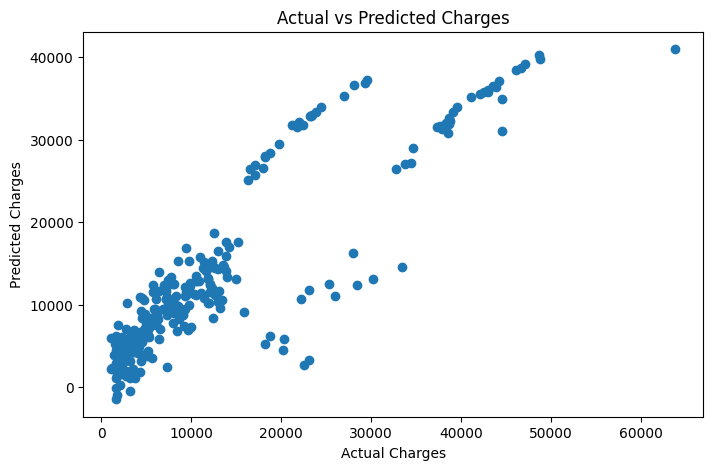

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [ ]:
print("\nEnter Patient Details")

age = int(input("Age: "))
sex = input("Sex (male/female): ")
bmi = float(input("BMI: "))
children = int(input("Children: "))
smoker = input("Smoker (yes/no): ")
region = input("Region (southwest/southeast/northwest/northeast): ")


Enter Patient Details


In [ ]:
sex = le.fit(df["sex"]).transform([0])[0] if False else (1 if sex.lower()=="male" else 0)
smoker = 1 if smoker.lower()=="yes" else 0

region_dict = {
    "northeast":0,
    "northwest":1,
    "southeast":2,
    "southwest":3
}
region = region_dict[region.lower()]

In [ ]:
prediction = model.predict([[age, sex, bmi, children, smoker, region]])

print("\nPredicted Medical Insurance Charges: ₹", round(prediction[0],2))